In [ ]:

# ========================================
# Logistic Regression Example: Predicting Default Probability
# ========================================
# G.Vinueza 20250902


# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)
import statsmodels.api as sm


In [11]:

# Step 2: Load dataset
df = pd.read_csv("Dataset_Default.csv")

In [12]:
df.shape

(100, 5)

In [13]:
# Step 3: Data Cleaning
# Remove $ and commas, convert to numeric
for col in ["Income", "Loan_Amount"]:
    df[col] = (
        df[col]
        .replace({'\$':'', ',':''}, regex=True)
        .astype(float)
    )


<>:6: SyntaxWarning: invalid escape sequence '\$'
<>:6: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-1023687183.py:6: SyntaxWarning: invalid escape sequence '\$'
  .replace({'\$':'', ',':''}, regex=True)


In [14]:
df.head()

,Age,Income,Loan_Amount,Has_Credit_Card,Default
0,56,1064.0,3755.0,0,1
1,69,9006.0,4718.0,1,1
2,46,3568.0,4996.0,0,0
3,32,6463.0,1266.0,0,1
4,60,3027.0,4889.0,0,1


   Age  Income  Loan_Amount  Has_Credit_Card  Default
0   56  1064.0       3755.0                0        1
1   69  9006.0       4718.0                1        1
2   46  3568.0       4996.0                0        0
3   32  6463.0       1266.0                0        1
4   60  3027.0       4889.0                0        1

              Age       Income  Loan_Amount  Has_Credit_Card     Default
count  100.000000   100.000000    100.00000       100.000000  100.000000
mean    43.350000  5647.670000   2875.95000         0.540000    0.380000
std     14.904663  2494.881257   1291.55463         0.500908    0.487832
min     19.000000  1064.000000    516.00000         0.000000    0.000000
25%     31.750000  3661.750000   1736.75000         0.000000    0.000000
50%     42.000000  6153.000000   2998.00000         1.000000    0.000000
75%     57.000000  7746.000000   3876.00000         1.000000    1.000000
max     69.000000  9996.000000   4999.00000         1.000000    1.000000

Age              

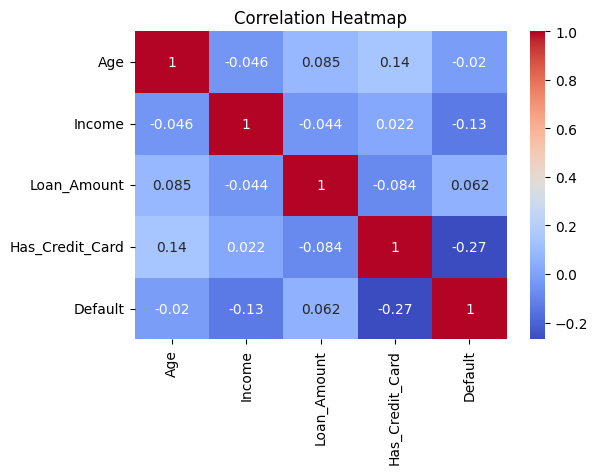

In [15]:
# Step 4: Exploratory Data Analysis (EDA)
print(df.head())          # Look at data
print("")
print(df.describe())      # Summary stats
print("")
print(df.isnull().sum())  # Missing values check
print("")

# Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()



In [17]:
# Step 5: Define features and target
X = df[["Age", "Income", "Loan_Amount", "Has_Credit_Card"]]
y = df["Default"]

# Step 6: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Step 7: Train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Step 8: Predictions
y_pred = model.predict(X_test)             # Predicted classes
y_pred_proba = model.predict_proba(X_test)[:,1]  # Probabilities for class 1 (Default)


# ===============================
# How to Read the Confusion Matrix:
# ===============================
# The confusion matrix is a 2x2 table that compares predictions vs. actual values:
#
#               Predicted: 0     Predicted: 1
# Actual: 0   -> True Negative     False Positive
# Actual: 1   -> False Negative    True Positive
#
# - True Negative (TN): Model correctly predicts NO default.
# - False Positive (FP): Model predicts default, but actually it was NO default. (Type I Error)
# - False Negative (FN): Model predicts NO default, but actually it WAS a default. (Type II Error)
# - True Positive (TP): Model correctly predicts default.
#
# For example:
# [[TN, FP],
#  [FN, TP]]
#
# From this table we can calculate:
# - Accuracy  = (TP + TN) / total
# - Precision = TP / (TP + FP)  -> Of those predicted default, how many were correct?
# - Recall    = TP / (TP + FN)  -> Of actual defaults, how many did we catch?
# - F1 Score  = Balance between precision and recall.

# ===============================
# Notes
# ===============================
# - Confusion Matrix shows how many predictions were correct/incorrect.
# - Classification Report gives Precision, Recall, and F1-score.
# - ROC Curve shows trade-off between sensitivity and specificity.
# - AUC (Area Under Curve) measures how well the model separates classes.
# - Statsmodels summary includes p-values for each variable's significance.


# Step 9: Evaluation Metrics
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[17 10]
 [ 8  5]]


In [18]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC AUC Score:", roc_auc_score(y_test, y_pred_proba))


Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.63      0.65        27
           1       0.33      0.38      0.36        13

    accuracy                           0.55        40
   macro avg       0.51      0.51      0.51        40
weighted avg       0.57      0.55      0.56        40


ROC AUC Score: 0.584045584045584


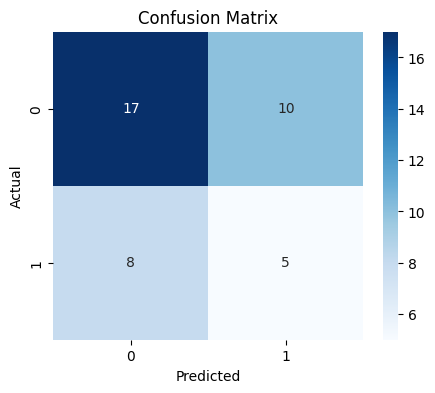

In [19]:
# Step 10: Confusion Matrix Heatmap
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



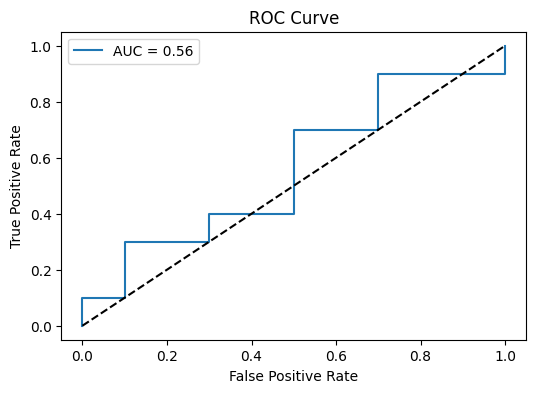

Optimization terminated successfully.
         Current function value: 0.618028
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                Default   No. Observations:                  100
Model:                          Logit   Df Residuals:                       95
Method:                           MLE   Df Model:                            4
Date:                Tue, 02 Sep 2025   Pseudo R-squ.:                 0.06932
Time:                        01:19:55   Log-Likelihood:                -61.803
converged:                       True   LL-Null:                       -66.406
Covariance Type:            nonrobust   LLR p-value:                   0.05612
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.4867      0.979      0.497      0.619      -1.432       2.406
Age           

In [10]:
# Step 11: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred_proba):.2f}")
plt.plot([0,1], [0,1], "k--")  # Random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
# ===============================
# How to Read the ROC Curve:
# ===============================
# ROC stands for "Receiver Operating Characteristic" curve.
# It shows how well the model can separate the two classes (Default vs No Default).
#
# - The X-axis is the False Positive Rate (FPR).
#   -> Out of all NO defaults, how many were incorrectly predicted as defaults?
#
# - The Y-axis is the True Positive Rate (TPR), also called Recall.
#   -> Out of all actual defaults, how many did we correctly identify?
#
# - Each point on the curve corresponds to a different threshold
#   (the probability cutoff used to decide between Default=1 and Default=0).
#
# - The diagonal line (from bottom-left to top-right) represents random guessing.
#   If the model's curve is close to this line, the model is not better than chance.
#
# - The further the ROC curve bows towards the top-left corner, the better the model.
#   That means it catches more defaults while making fewer mistakes.
#
# - AUC (Area Under Curve) summarizes the ROC curve in one number.
#   - AUC = 0.5 means the model is no better than random.
#   - AUC = 1.0 means perfect classification.
#   - AUC above 0.7 is usually considered acceptable, above 0.8 good, and above 0.9 excellent.



In [ ]:

# Step 12: Statsmodels for coefficients and p-values
X_sm = sm.add_constant(X)  # Add intercept
model_sm = sm.Logit(y, X_sm).fit()
print(model_sm.summary())

# ===============================
# Step 12: Understanding Statsmodels Output
# ===============================
# Statsmodels allows us to go deeper into the logistic regression results.
#
# - Coef (Coefficient):
#   Shows the effect of each variable on the probability of default.
#   Positive coef → increases chance of default.
#   Negative coef → decreases chance of default.
#
# - P>|z| (P-value):
#   Tells us if the variable is statistically significant.
#   If p-value < 0.05, the variable is usually considered important.
#
# - Log-Likelihood:
#   A measure of model fit. Higher (less negative) values = better fit.
#
# - LR statistic and Prob (Chi²):
#   Test whether the overall model is statistically significant.
#
# - Pseudo R²:
#   Similar idea to R² in linear regression, but adapted for logistic regression.
#   Shows how much of the variation in "Default" is explained by the predictors.
#
# In summary:
# This step helps us understand *which variables matter most*
# and *whether the model as a whole is reliable*.
